# Model Evaluation

This notebook loads and evaluates previously trained and saved models by plotting their training and validation accuracy and loss curves, and assessing performance on the test set. For each model, it reports test accuracy and loss, a confusion matrix, and a full classification report.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from tensorflow import keras
from tensorflow.keras.models import load_model
import pickle

2025-11-18 03:55:58.556215: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
data = np.load('../data/processed_data.npz')

X_train = data['X_train']
X_test = data['X_test']
X_val = data['X_val']

X_train_normalized = data['X_train_normalized']
X_test_normalized = data['X_test_normalized']
X_val_normalized = data['X_val_normalized']

y_train = data['y_train']
y_test = data['y_test']
y_val = data['y_val']

y_train_cat = data['y_train_cat']
y_test_cat = data['y_test_cat']
y_val_cat = data['y_val_cat']

In [3]:
# plots accuracy and loss training curves
def plot_training_curves(history, title):
    plt.figure(figsize=(12, 5))

    # accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='train')
    plt.plot(history['val_accuracy'], label='val')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy');
    plt.legend();
    
    # loss
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='train')
    plt.plot(history['val_loss'], label='val')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend();

    plt.show()

emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# evaluates model, test accuracy & loss, confusion matrix, classification report
def evaluate_model(model, X_test, y_test, title):
    # test results
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f'{title} - Test Accuracy: {test_accuracy:.4f} Test Loss: {test_loss:.4f}')
    
    # confusion matrix
    y_pred = np.argmax(model.predict(X_test), axis=1)
    y_true = np.argmax(y_test, axis=1)
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=emotion_labels).plot(cmap='Blues', xticks_rotation='vertical')
    plt.title(f'{title} - Confusion Matrix')
    plt.show()
    
    # classification report
    print(classification_report(y_true, y_pred, target_names=emotion_labels))
    

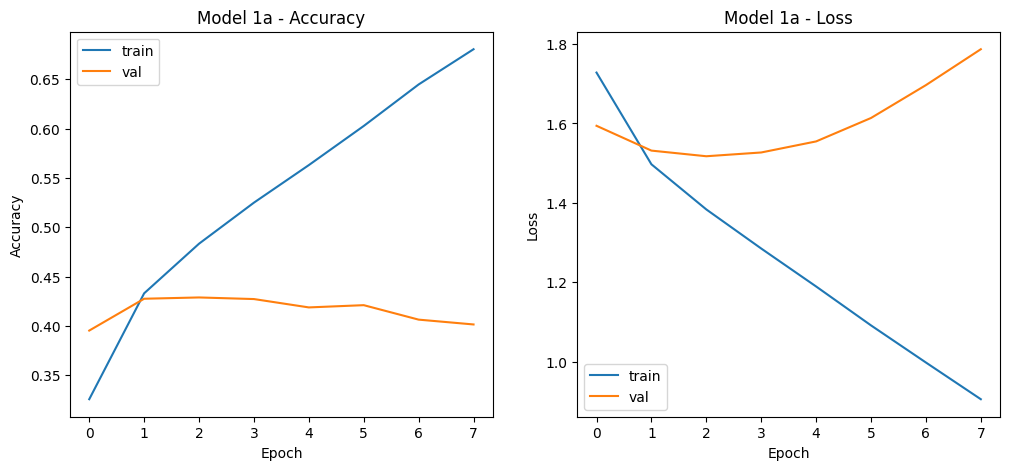

I0000 00:00:1763438170.764087    3230 service.cc:152] XLA service 0x7f2600008160 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1763438170.764157    3230 service.cc:160]   StreamExecutor device (0): Host, Default Version
2025-11-18 03:56:10.862495: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1763438171.743750    3230 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Model 1a - Test Accuracy: 0.4229 Test Loss: 1.5076
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step  


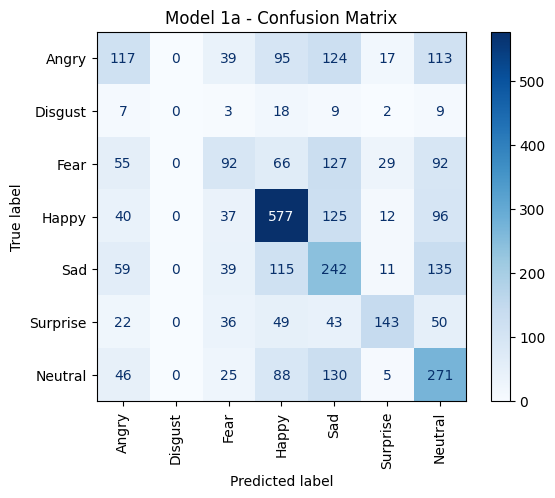

              precision    recall  f1-score   support

       Angry       0.34      0.23      0.27       505
     Disgust       0.00      0.00      0.00        48
        Fear       0.34      0.20      0.25       461
       Happy       0.57      0.65      0.61       887
         Sad       0.30      0.40      0.35       601
    Surprise       0.65      0.42      0.51       343
     Neutral       0.35      0.48      0.41       565

    accuracy                           0.42      3410
   macro avg       0.37      0.34      0.34      3410
weighted avg       0.42      0.42      0.41      3410



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [4]:
model_1a = load_model('../models/model_1a.keras')

with open('../history/history_1a.pkl', 'rb') as f:
    history_1a = pickle.load(f)

plot_training_curves(history_1a, "Model 1a")
evaluate_model(model_1a, X_test_normalized, y_test_cat, "Model 1a")

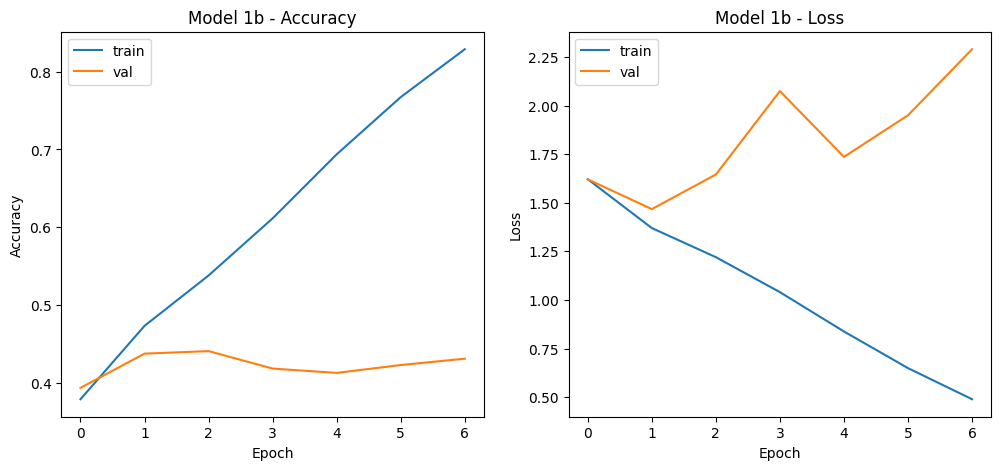

Model 1b - Test Accuracy: 0.4270 Test Loss: 1.4753
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step  


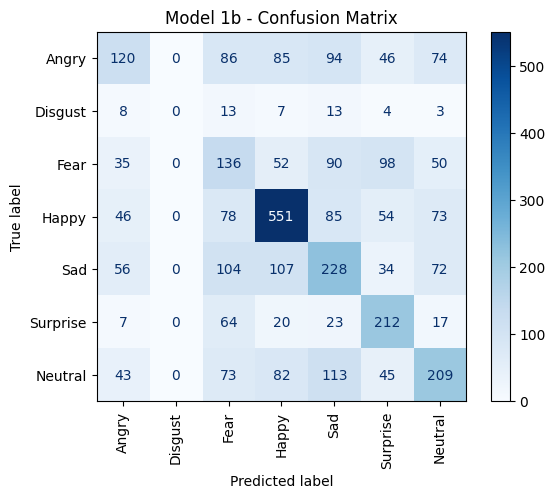

              precision    recall  f1-score   support

       Angry       0.38      0.24      0.29       505
     Disgust       0.00      0.00      0.00        48
        Fear       0.25      0.30      0.27       461
       Happy       0.61      0.62      0.62       887
         Sad       0.35      0.38      0.37       601
    Surprise       0.43      0.62      0.51       343
     Neutral       0.42      0.37      0.39       565

    accuracy                           0.43      3410
   macro avg       0.35      0.36      0.35      3410
weighted avg       0.42      0.43      0.42      3410



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [5]:
model_1b = load_model('../models/model_1b.keras')

with open('../history/history_1b.pkl', 'rb') as f:
    history_1b = pickle.load(f)

plot_training_curves(history_1b, "Model 1b")
evaluate_model(model_1b, X_test_normalized, y_test_cat, "Model 1b")

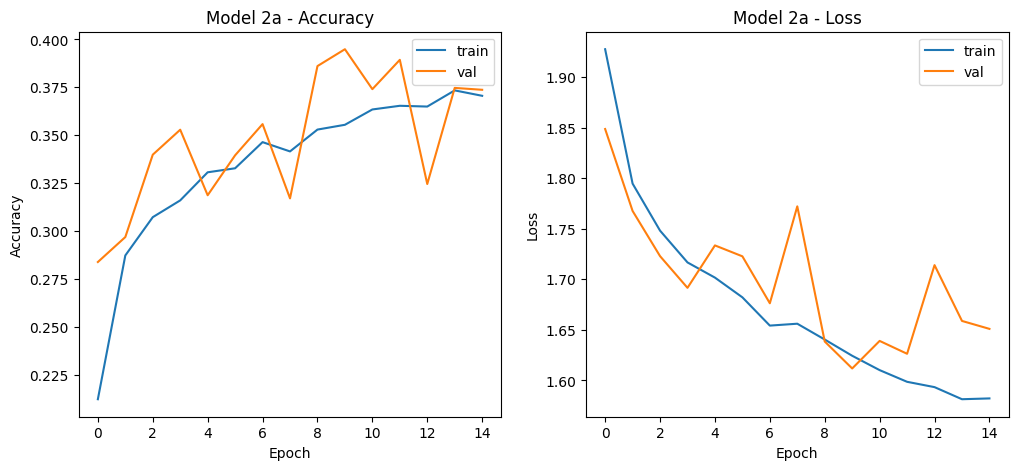

Model 2a - Test Accuracy: 0.3809 Test Loss: 1.6289
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step  


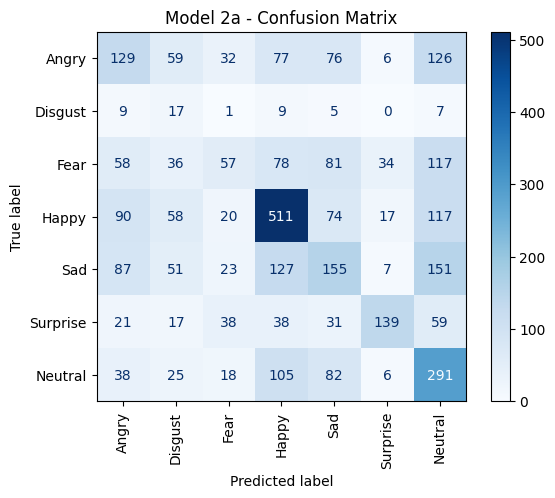

              precision    recall  f1-score   support

       Angry       0.30      0.26      0.28       505
     Disgust       0.06      0.35      0.11        48
        Fear       0.30      0.12      0.18       461
       Happy       0.54      0.58      0.56       887
         Sad       0.31      0.26      0.28       601
    Surprise       0.67      0.41      0.50       343
     Neutral       0.34      0.52      0.41       565

    accuracy                           0.38      3410
   macro avg       0.36      0.36      0.33      3410
weighted avg       0.40      0.38      0.38      3410



In [6]:
model_2a = load_model('../models/model_2a.keras')

with open('../history/history_2a.pkl', 'rb') as f:
    history_2a = pickle.load(f)

plot_training_curves(history_2a, "Model 2a")
evaluate_model(model_2a, X_test, y_test_cat, "Model 2a")

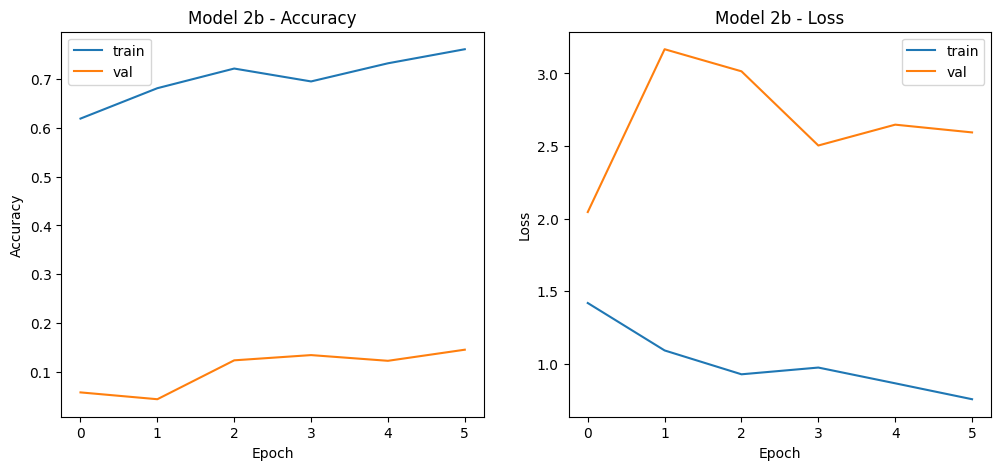

Model 2b - Test Accuracy: 0.0604 Test Loss: 2.0475
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step  


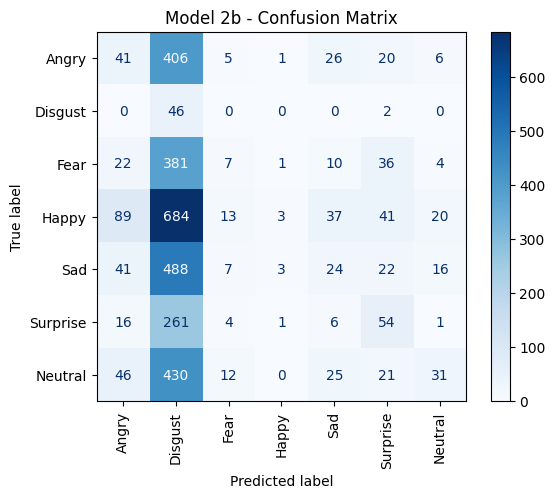

              precision    recall  f1-score   support

       Angry       0.16      0.08      0.11       505
     Disgust       0.02      0.96      0.03        48
        Fear       0.15      0.02      0.03       461
       Happy       0.33      0.00      0.01       887
         Sad       0.19      0.04      0.07       601
    Surprise       0.28      0.16      0.20       343
     Neutral       0.40      0.05      0.10       565

    accuracy                           0.06      3410
   macro avg       0.22      0.19      0.08      3410
weighted avg       0.26      0.06      0.07      3410



In [7]:
model_2b = load_model('../models/model_2b.keras')

with open('../history/history_2b.pkl', 'rb') as f:
    history_2b = pickle.load(f)

plot_training_curves(history_2b, "Model 2b")
evaluate_model(model_2b, X_test_normalized, y_test_cat, "Model 2b")

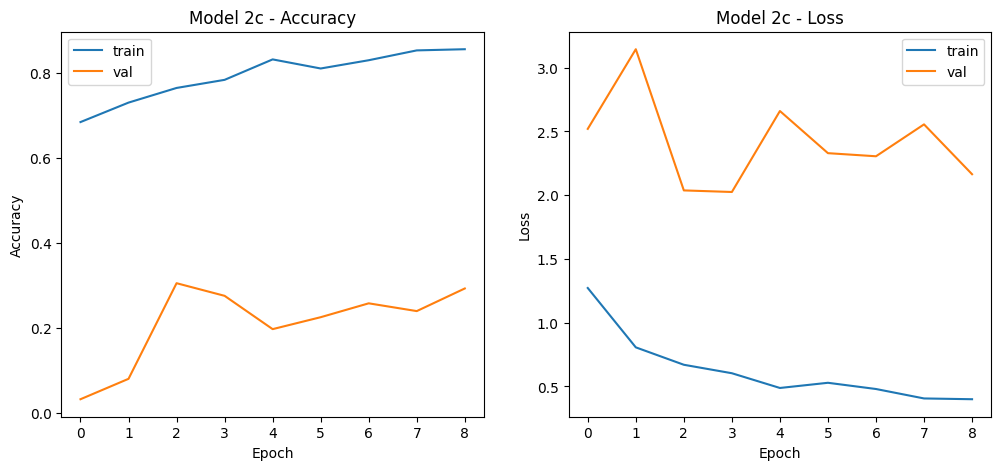

Model 2c - Test Accuracy: 0.2713 Test Loss: 2.0138
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step


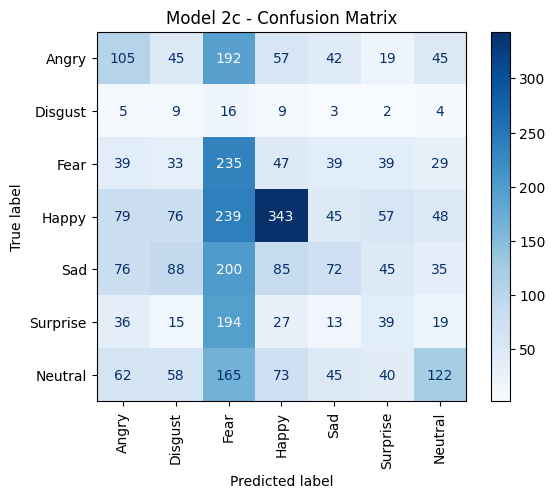

              precision    recall  f1-score   support

       Angry       0.26      0.21      0.23       505
     Disgust       0.03      0.19      0.05        48
        Fear       0.19      0.51      0.28       461
       Happy       0.54      0.39      0.45       887
         Sad       0.28      0.12      0.17       601
    Surprise       0.16      0.11      0.13       343
     Neutral       0.40      0.22      0.28       565

    accuracy                           0.27      3410
   macro avg       0.27      0.25      0.23      3410
weighted avg       0.34      0.27      0.28      3410



In [8]:
model_2c = load_model('../models/model_2c.keras')

with open('../history/history_2c.pkl', 'rb') as f:
    history_2c = pickle.load(f)

plot_training_curves(history_2c, "Model 2c")
evaluate_model(model_2c, X_test_normalized, y_test_cat, "Model 2c")

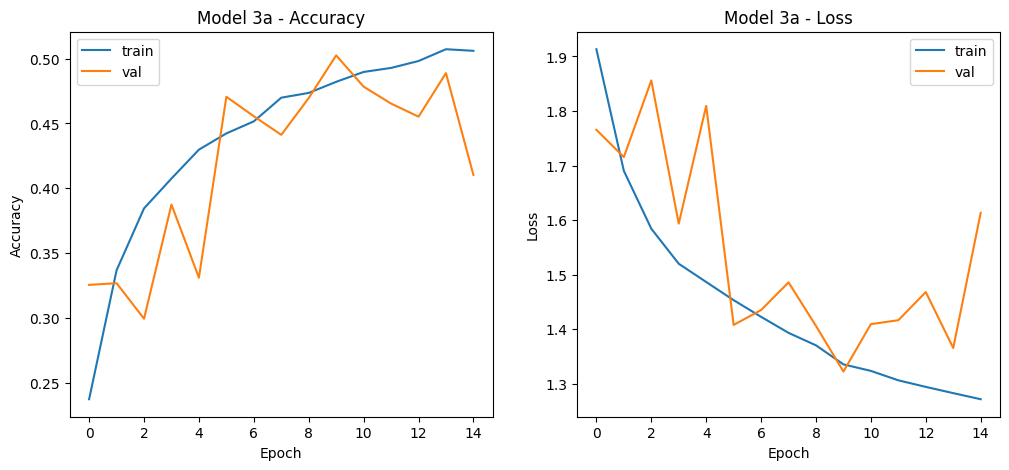

Model 3a - Test Accuracy: 0.4979 Test Loss: 1.3548
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


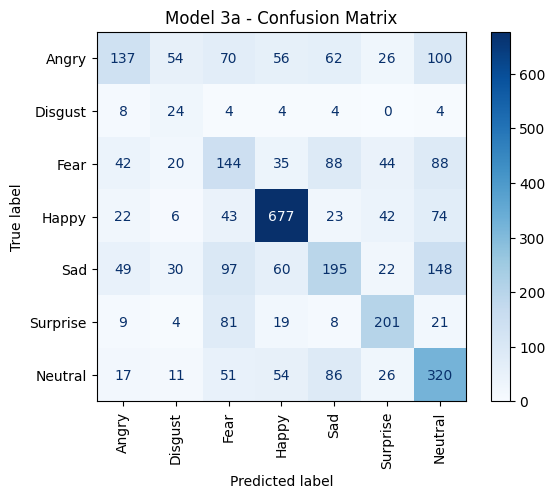

              precision    recall  f1-score   support

       Angry       0.48      0.27      0.35       505
     Disgust       0.16      0.50      0.24        48
        Fear       0.29      0.31      0.30       461
       Happy       0.75      0.76      0.76       887
         Sad       0.42      0.32      0.37       601
    Surprise       0.56      0.59      0.57       343
     Neutral       0.42      0.57      0.48       565

    accuracy                           0.50      3410
   macro avg       0.44      0.47      0.44      3410
weighted avg       0.51      0.50      0.49      3410



In [9]:
model_3a = load_model('../models/model_3a.keras')

with open('../history/history_3a.pkl', 'rb') as f:
    history_3a = pickle.load(f)

plot_training_curves(history_3a, "Model 3a")
evaluate_model(model_3a, X_test, y_test_cat, "Model 3a")

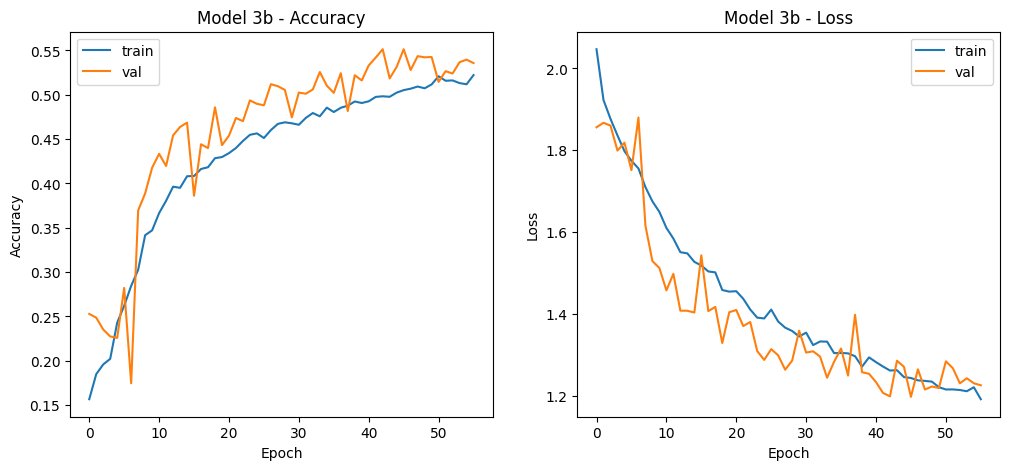

Model 3b - Test Accuracy: 0.5607 Test Loss: 1.1888
107/107 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step


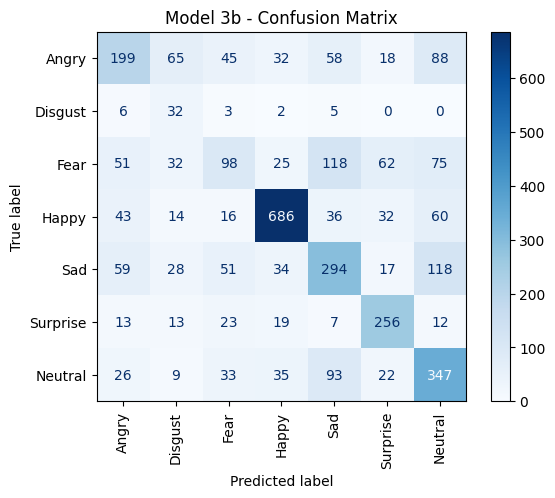

              precision    recall  f1-score   support

       Angry       0.50      0.39      0.44       505
     Disgust       0.17      0.67      0.27        48
        Fear       0.36      0.21      0.27       461
       Happy       0.82      0.77      0.80       887
         Sad       0.48      0.49      0.49       601
    Surprise       0.63      0.75      0.68       343
     Neutral       0.50      0.61      0.55       565

    accuracy                           0.56      3410
   macro avg       0.49      0.56      0.50      3410
weighted avg       0.57      0.56      0.56      3410



In [10]:
model_3b = load_model('../models/model_3b.keras')

with open('../history/history_3b.pkl', 'rb') as f:
    history_3b = pickle.load(f)

plot_training_curves(history_3b, "Model 3b")
evaluate_model(model_3b, X_test, y_test_cat, "Model 3b")

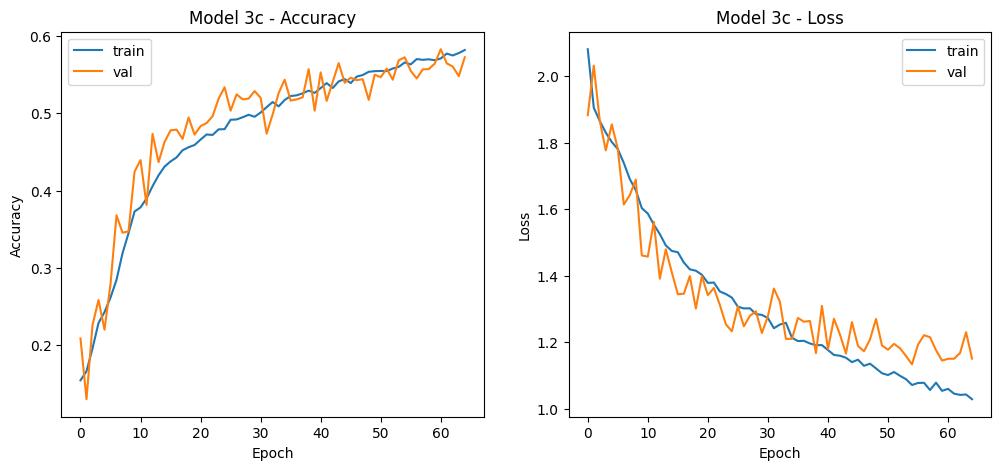

Model 3c - Test Accuracy: 0.5780 Test Loss: 1.1258
107/107 ━━━━━━━━━━━━━━━━━━━━ 17s 157ms/step


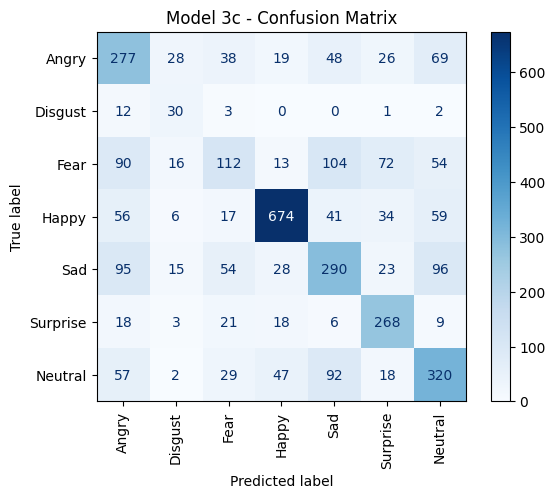

              precision    recall  f1-score   support

       Angry       0.46      0.55      0.50       505
     Disgust       0.30      0.62      0.41        48
        Fear       0.41      0.24      0.30       461
       Happy       0.84      0.76      0.80       887
         Sad       0.50      0.48      0.49       601
    Surprise       0.61      0.78      0.68       343
     Neutral       0.53      0.57      0.55       565

    accuracy                           0.58      3410
   macro avg       0.52      0.57      0.53      3410
weighted avg       0.58      0.58      0.57      3410



In [11]:
model_3c = load_model('../models/model_3c.keras')

with open('../history/history_3c.pkl', 'rb') as f:
    history_3c = pickle.load(f)

plot_training_curves(history_3c, "Model 3c")
evaluate_model(model_3c, X_test, y_test_cat, "Model 3c")

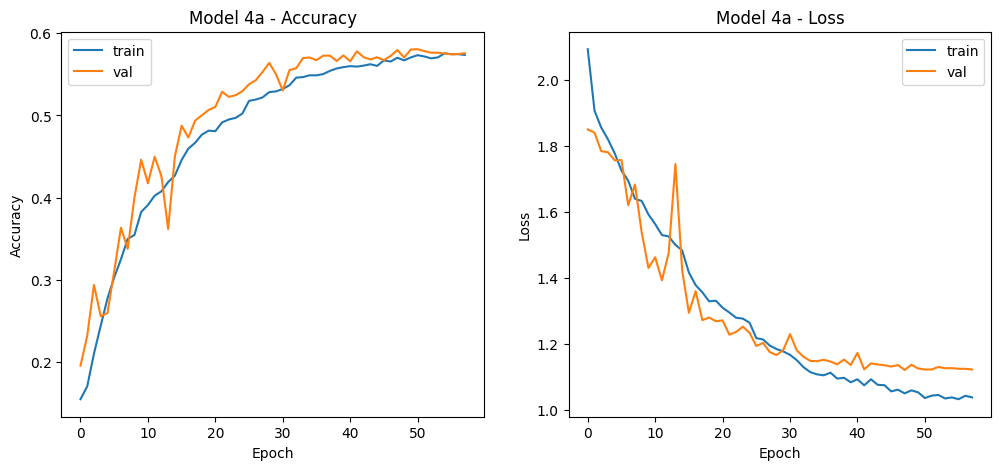

Model 4a - Test Accuracy: 0.5833 Test Loss: 1.1133
107/107 ━━━━━━━━━━━━━━━━━━━━ 14s 129ms/step


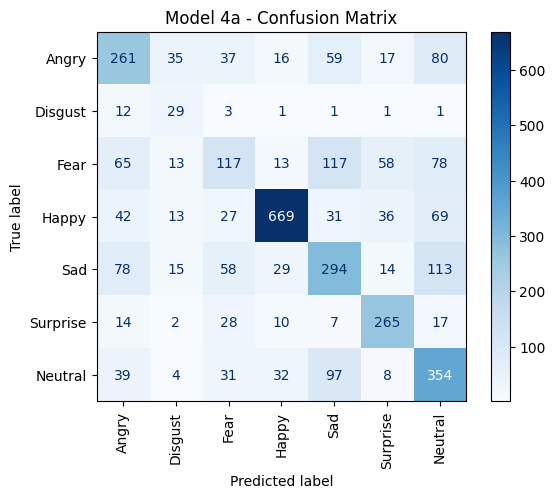

              precision    recall  f1-score   support

       Angry       0.51      0.52      0.51       505
     Disgust       0.26      0.60      0.36        48
        Fear       0.39      0.25      0.31       461
       Happy       0.87      0.75      0.81       887
         Sad       0.49      0.49      0.49       601
    Surprise       0.66      0.77      0.71       343
     Neutral       0.50      0.63      0.55       565

    accuracy                           0.58      3410
   macro avg       0.53      0.57      0.54      3410
weighted avg       0.59      0.58      0.58      3410



In [12]:
model_4a = load_model('../models/model_4a.keras')

with open('../history/history_4a.pkl', 'rb') as f:
    history_4a = pickle.load(f)

plot_training_curves(history_4a, "Model 4a")
evaluate_model(model_4a, X_test, y_test_cat, "Model 4a")

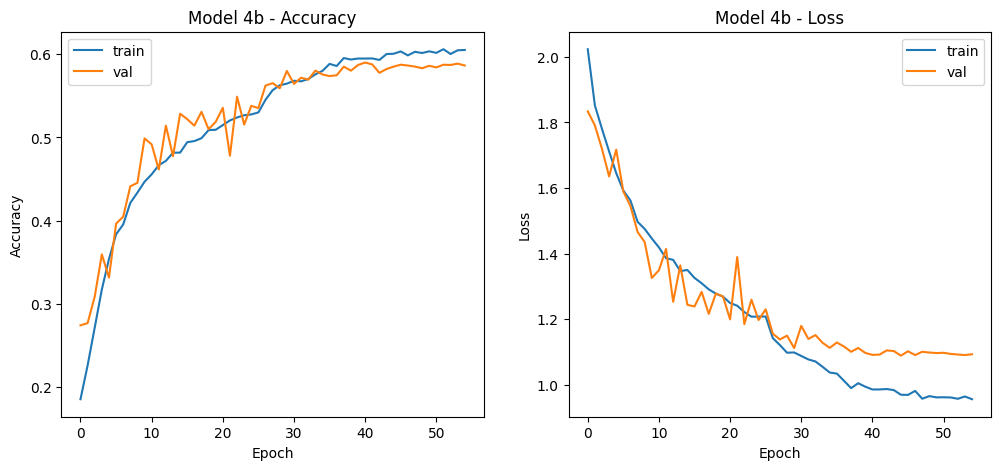

Model 4b - Test Accuracy: 0.5933 Test Loss: 1.0941
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 133ms/step


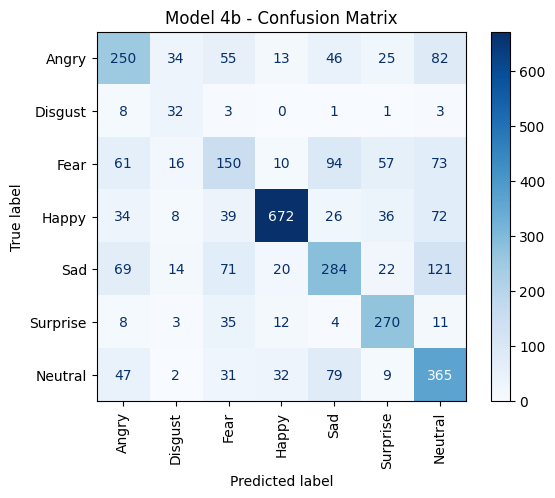

              precision    recall  f1-score   support

       Angry       0.52      0.50      0.51       505
     Disgust       0.29      0.67      0.41        48
        Fear       0.39      0.33      0.36       461
       Happy       0.89      0.76      0.82       887
         Sad       0.53      0.47      0.50       601
    Surprise       0.64      0.79      0.71       343
     Neutral       0.50      0.65      0.57       565

    accuracy                           0.59      3410
   macro avg       0.54      0.59      0.55      3410
weighted avg       0.61      0.59      0.59      3410



In [13]:
model_4b = load_model('../models/model_4b.keras')

with open('../history/history_4b.pkl', 'rb') as f:
    history_4b = pickle.load(f)

plot_training_curves(history_4b, "Model 4b")
evaluate_model(model_4b, X_test, y_test_cat, "Model 4b")

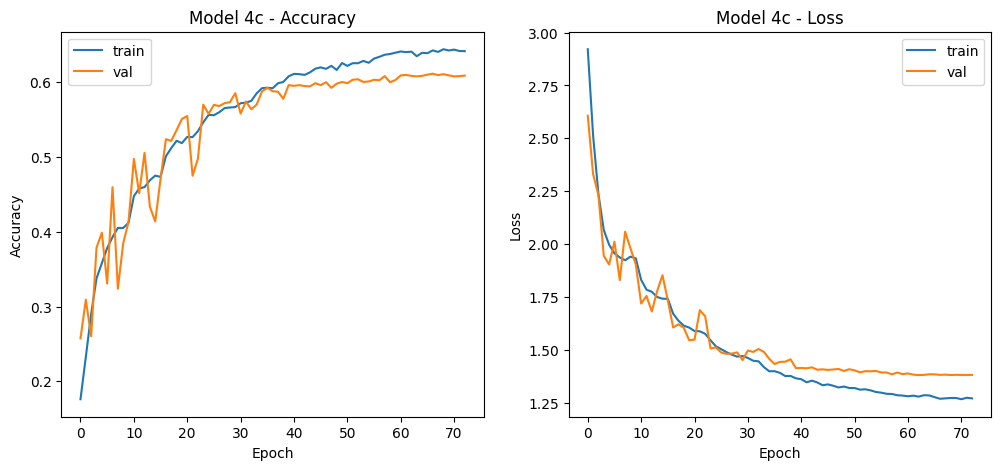

Model 4c - Test Accuracy: 0.6129 Test Loss: 1.3776
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 134ms/step


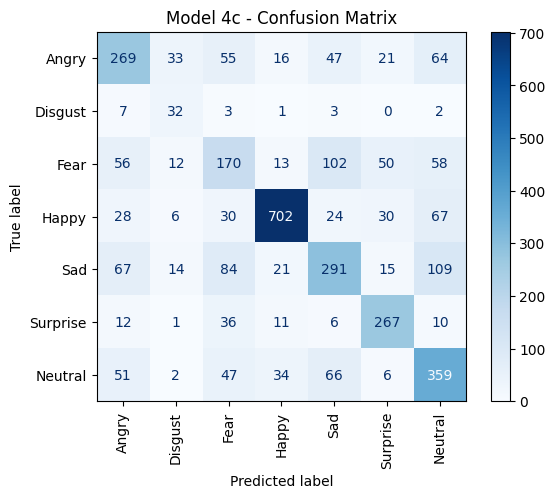

              precision    recall  f1-score   support

       Angry       0.55      0.53      0.54       505
     Disgust       0.32      0.67      0.43        48
        Fear       0.40      0.37      0.38       461
       Happy       0.88      0.79      0.83       887
         Sad       0.54      0.48      0.51       601
    Surprise       0.69      0.78      0.73       343
     Neutral       0.54      0.64      0.58       565

    accuracy                           0.61      3410
   macro avg       0.56      0.61      0.57      3410
weighted avg       0.62      0.61      0.61      3410



In [14]:
model_4c = load_model('../models/model_4c.keras')

with open('../history/history_4c.pkl', 'rb') as f:
    history_4c = pickle.load(f)

plot_training_curves(history_4c, "Model 4c")
evaluate_model(model_4c, X_test, y_test_cat, "Model 4c")

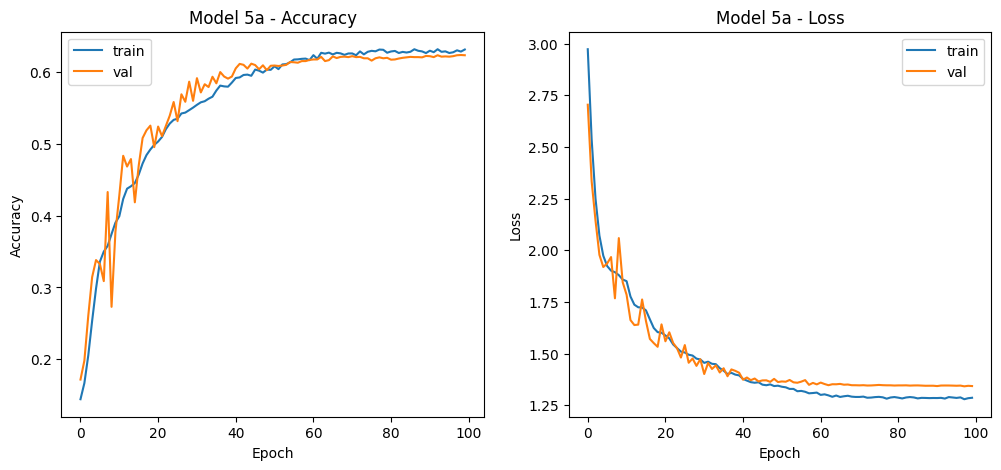

Model 5a - Test Accuracy: 0.6282 Test Loss: 1.3361
107/107 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step


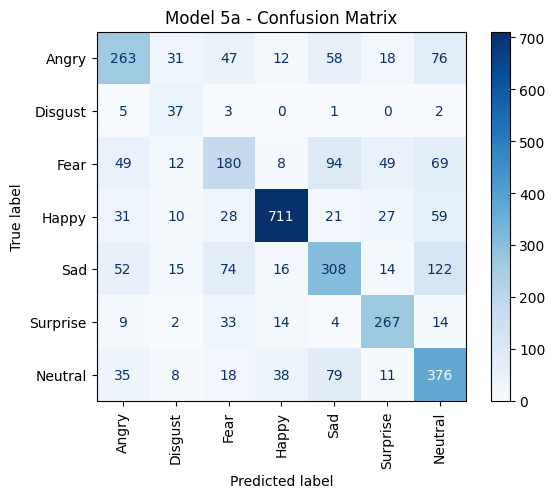

              precision    recall  f1-score   support

       Angry       0.59      0.52      0.55       505
     Disgust       0.32      0.77      0.45        48
        Fear       0.47      0.39      0.43       461
       Happy       0.89      0.80      0.84       887
         Sad       0.55      0.51      0.53       601
    Surprise       0.69      0.78      0.73       343
     Neutral       0.52      0.67      0.59       565

    accuracy                           0.63      3410
   macro avg       0.58      0.63      0.59      3410
weighted avg       0.64      0.63      0.63      3410



In [15]:
model_5a = load_model('../models/model_5a.keras')

with open('../history/history_5a.pkl', 'rb') as f:
    history_5a = pickle.load(f)

plot_training_curves(history_5a, "Model 5a")
evaluate_model(model_5a, X_test, y_test_cat, "Model 5a")